# モーメント編集データで学習したモデルの評価

読み込めたレコード: ['plain_step47921', 'plain_step62059', 'del_conrad', 'del_gaussian', 'del_ics', 'del_truncated_normal', 'del_third_order_gram_seed42']
plain_step47921                  step= 47921 accept_mb=0.515  accept_fb=N/A  dist_final=N/A
plain_step62059                  step= 62059 accept_mb=0.515  accept_fb=N/A  dist_final=N/A
del_conrad                       step= 62000 accept_mb=0.525  accept_fb=0.5892132644684367  dist_final=73.61174011230469
del_gaussian                     step= 62000 accept_mb=0.514  accept_fb=0.5223066506849646  dist_final=73.6030502319336
del_ics                          step= 62000 accept_mb=0.642  accept_fb=0.7648082244451809  dist_final=73.61265563964844
del_truncated_normal             step= 62000 accept_mb=0.508  accept_fb=0.5186796643164676  dist_final=73.60307312011719
del_third_order_gram_seed42      step= 62000 accept_mb=0.516  accept_fb=0.5355905775700152  dist_final=73.6062240600586


/tmp/ipykernel_160767/2282751116.py:74: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_160767/2282751116.py:74: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


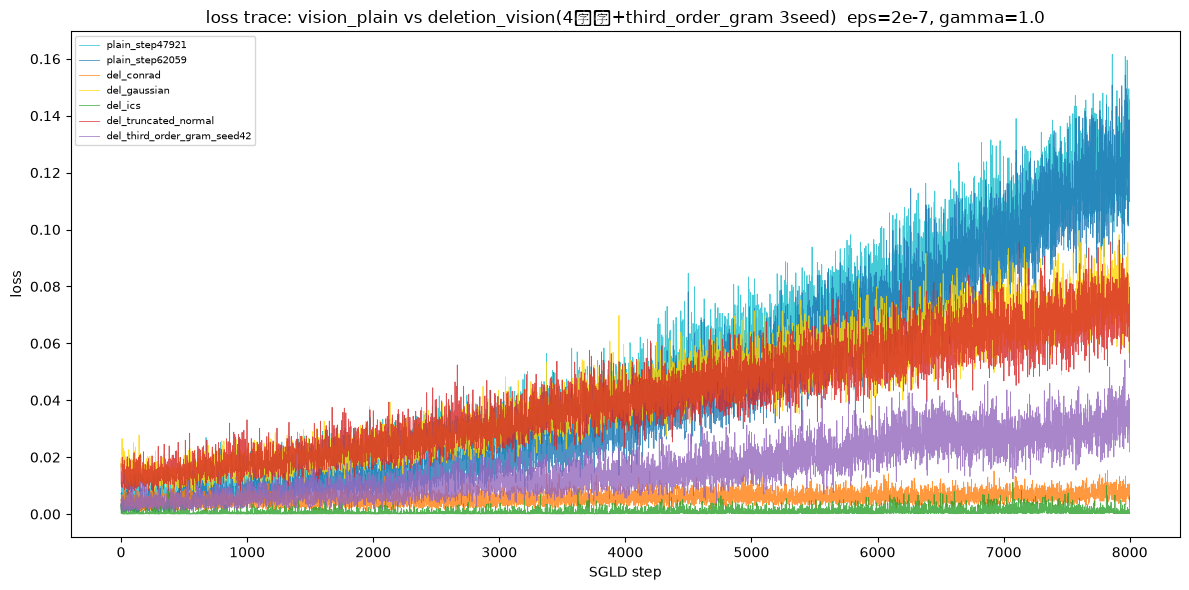

plain_step47921                  ['209.10', '267.88', '312.61', '329.53']
plain_step62059                  ['189.71', '245.44', '290.34', '307.74']
del_conrad                       ['8.85', '10.67', '11.90', '12.22']
del_gaussian                     ['109.07', '146.71', '173.29', '181.91']
del_ics                          ['-7.54', '-7.08', '-6.56', '-6.38']
del_truncated_normal             ['129.97', '164.49', '186.92', '193.92']
del_third_order_gram_seed42      ['58.10', '73.48', '84.00', '88.19']


/tmp/ipykernel_160767/2282751116.py:116: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_160767/2282751116.py:116: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


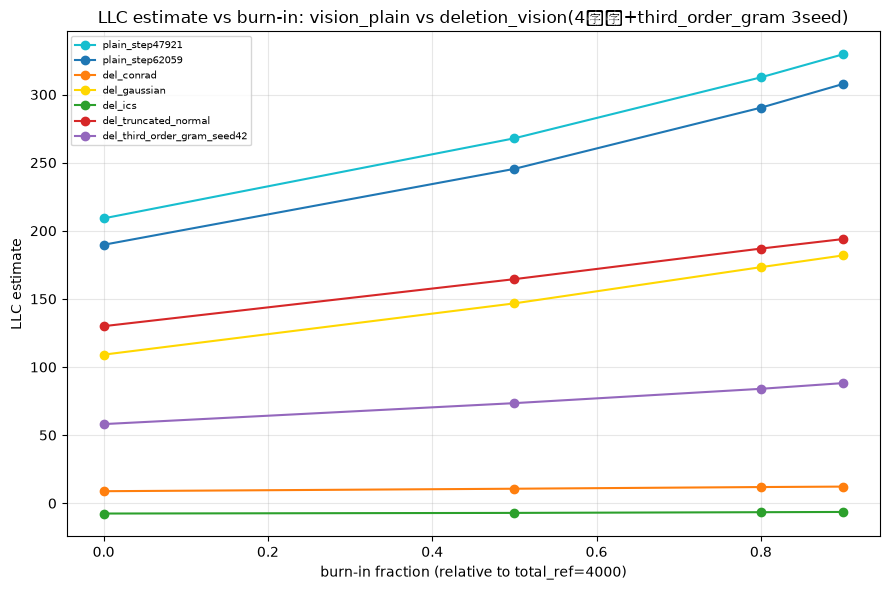

In [4]:
# ── 統合セル: vision_plain + deletion(4手法) + third_order_gram(3seed正式版) ──
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- vision_plain (通常学習) ---
VISION_PLAIN_ROOT = Path("/home/nakano/server/calibration_results_vision_resnet_setting")
vision_plain_records = {}
for f in VISION_PLAIN_ROOT.glob("calib_convnext-atto_step*.json"):
    d = json.load(open(f))
    for r in d["records"]:
        if abs(r["epsilon"] - 2e-7) < 1e-9 and r["gamma"] == 1.0 and r["total_steps"] == 8000:
            vision_plain_records[f"plain_step{r['step']}"] = r

# --- deletion_vision (既存4手法) ---
DELETION_ROOT = Path("/home/nakano/server/calibration_results_deletion_vision_resnet_setting")
METHODS = ["conrad", "gaussian", "ics", "truncated_normal"]
deletion_records = {}
for method in METHODS:
    f = DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_step62000.json"
    if not f.exists():
        print(f"{method}: NOT FOUND ({f})")
        continue
    d = json.load(open(f))
    recs = [r for r in d["records"] if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000]
    if recs:
        deletion_records[f"del_{method}"] = recs[0]
    else:
        print(f"{method}: file exists but no matching record")

# --- third_order_gram (正式版・3seed、ファイル名バグ修正後の再計算結果) ---
for seed in ["seed42"]: #, "seed43", "seed44"]:
    f = DELETION_ROOT / f"calib_convnext-atto_deletion_third_order_gram_{seed}_step62000.json"
    if not f.exists():
        print(f"third_order_gram {seed}: NOT FOUND ({f})")
        continue
    d = json.load(open(f))
    recs = [r for r in d["records"] if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000]
    if recs:
        deletion_records[f"del_third_order_gram_{seed}"] = recs[0]
    else:
        print(f"third_order_gram {seed}: file exists but no matching record")

# 統合
all_records = {**vision_plain_records, **deletion_records}
print("読み込めたレコード:", list(all_records.keys()))
for name, r in all_records.items():
    print(f"{name:32s} step={r['step']:6d} accept_mb={r['mean_accept_prob_full']:.3f}  "
          f"accept_fb={r.get('fixed_batch_mala_accept_mean', 'N/A')}  "
          f"dist_final={r.get('weight_distance_final', 'N/A')}")

# ── 色分け ──
colors = {
    "plain_step47921": "tab:cyan",
    "plain_step62059": "tab:blue",
    "del_conrad": "tab:orange",
    "del_gaussian": "gold",
    "del_ics": "tab:green",
    "del_truncated_normal": "tab:red",
    "del_third_order_gram_seed42": "tab:purple",
    #"del_third_order_gram_seed43": "mediumorchid",
    #"del_third_order_gram_seed44": "rebeccapurple",
}

# ── loss trace 比較 ──
fig, ax = plt.subplots(figsize=(12, 6))
for name, r in all_records.items():
    ax.plot(r["loss_trace"], linewidth=0.6, label=name, color=colors.get(name), alpha=0.8)
ax.set_xlabel("SGLD step")
ax.set_ylabel("loss")
ax.set_title("loss trace: vision_plain vs deletion_vision(4手法+third_order_gram 3seed)  eps=2e-7, gamma=1.0")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── burn-in を揃えたLLC比較 ──
def compute_llc_from_trace(loss_trace, l_w_star, nbeta,
                             burn_in_frac=0.0, burn_in_steps=None, total_ref=None):
    loss_trace = np.array(loss_trace)
    if burn_in_steps is not None:
        n_burn = burn_in_steps
    else:
        base = total_ref if total_ref is not None else len(loss_trace)
        n_burn = int(base * burn_in_frac)
    n_burn = min(n_burn, len(loss_trace) - 1)
    tail = loss_trace[n_burn:]
    return nbeta * (np.mean(tail) - l_w_star)

burn_in_fracs = [0.0, 0.5, 0.8, 0.9]
total_ref = 4000

llc_by_burnin = {name: [] for name in all_records}

for name, r in all_records.items():
    l_w_star_approx = np.mean(r["loss_trace"][:5])
    nbeta = r["nbeta"]
    for frac in burn_in_fracs:
        llc = compute_llc_from_trace(
            r["loss_trace"], l_w_star_approx, nbeta,
            burn_in_frac=frac, total_ref=total_ref)
        llc_by_burnin[name].append(llc)

for name in all_records:
    print(f"{name:32s}", [f"{v:.2f}" for v in llc_by_burnin[name]])

# ── burn-in vs LLC 折れ線 ──
fig, ax = plt.subplots(figsize=(9, 6))
for name in all_records:
    ax.plot(burn_in_fracs, llc_by_burnin[name], marker="o", label=name, color=colors.get(name))
ax.set_xlabel(f"burn-in fraction (relative to total_ref={total_ref})")
ax.set_ylabel("LLC estimate")
ax.set_title("LLC estimate vs burn-in: vision_plain vs deletion_vision(4手法+third_order_gram 3seed)")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 通常学習 (vision_plain, ConvNeXt-atto) との比較

plain test curve: (112, 3)  plain train_loss curve: (620, 2)
plain step range: 1 - 62059


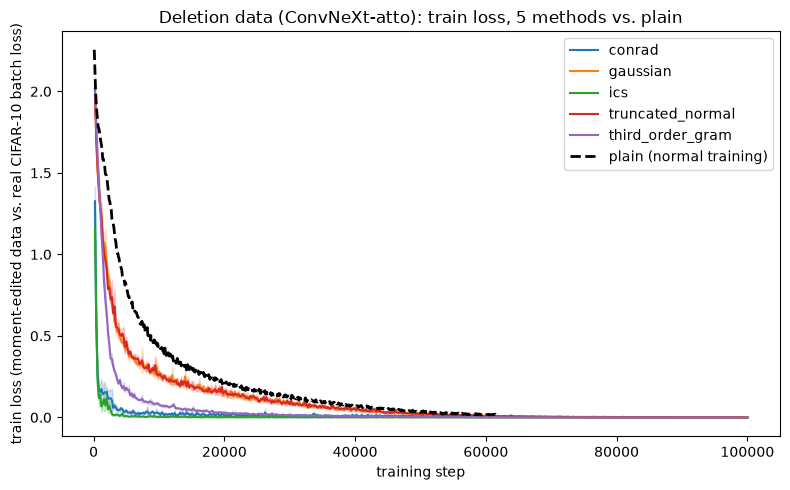

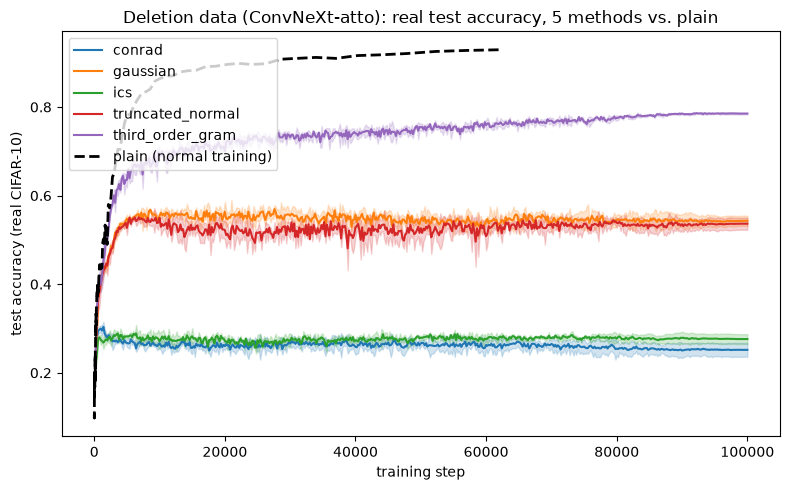

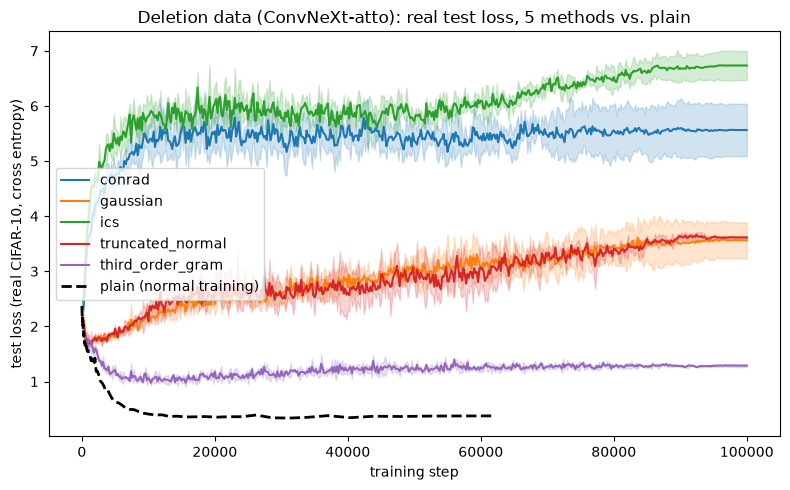

In [2]:
from pathlib import Path

# ── 通常学習 (vision_plain, 編集なしのCIFAR-10で学習) のデータを読み込む ──
PLAIN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10/convnext-atto")

# test_acc, test_loss: 各チェックポイントで実CIFAR-10テストセットを評価したもの
plain_test = pd.read_csv(PLAIN_ROOT / "eval_curve.csv").sort_values("step")

# train_loss: 学習中の(バッチ単位の)cross entropy loss。trainer_state.jsonのlog_historyに
# 100stepごとに記録されている。最終チェックポイント(最大step)のtrainer_state.jsonには
# それまでの全履歴が入っている。
ckpt_steps = sorted(
    int(d.name.split("-")[1]) for d in PLAIN_ROOT.glob("checkpoint-*")
)
final_ckpt = PLAIN_ROOT / f"checkpoint-{ckpt_steps[-1]}"
with open(final_ckpt / "trainer_state.json") as f:
    log_history = json.load(f)["log_history"]
plain_train_loss = pd.DataFrame(
    [{"step": e["step"], "train_loss": e["loss"]} for e in log_history if "loss" in e]
).sort_values("step")

print("plain test curve:", plain_test.shape, " plain train_loss curve:", plain_train_loss.shape)
print("plain step range:", plain_test["step"].min(), "-", plain_test["step"].max())

# 注: vision_plain側は編集データ全体でのtrain_acc(訓練データ全体に対する精度)を
# 学習中に記録していないため、train_accの比較は行えない(train_lossのみ比較可能)。

PLAIN_COLOR = "black"

def plot_metric_with_plain(metric_name, plain_df, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, method in enumerate(METHODS):
        sub = summary[summary["method"] == method].sort_values("step")
        ax.plot(sub["step"], sub[f"{metric_name}_mean"], label=method, color=colors[i])
        ax.fill_between(
            sub["step"],
            sub[f"{metric_name}_mean"] - sub[f"{metric_name}_std"],
            sub[f"{metric_name}_mean"] + sub[f"{metric_name}_std"],
            color=colors[i], alpha=0.2,
        )
    ax.plot(
        plain_df["step"], plain_df[metric_name],
        label="plain (normal training)", color=PLAIN_COLOR,
        linestyle="--", linewidth=2,
    )
    ax.set_xlabel("training step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"/home/nakano/server/llc_results_dense/{save_name}.png", dpi=150)
    plt.show()

plot_metric_with_plain(
    "train_loss", plain_train_loss,
    "train loss (moment-edited data vs. real CIFAR-10 batch loss)",
    "Deletion data (ConvNeXt-atto): train loss, 5 methods vs. plain",
    "deletion_vision_train_loss_gram_vs_plain",
)

plot_metric_with_plain(
    "test_acc", plain_test,
    "test accuracy (real CIFAR-10)",
    "Deletion data (ConvNeXt-atto): real test accuracy, 5 methods vs. plain",
    "deletion_vision_test_acc_gram_vs_plain",
)

plot_metric_with_plain(
    "test_loss", plain_test,
    "test loss (real CIFAR-10, cross entropy)",
    "Deletion data (ConvNeXt-atto): real test loss, 5 methods vs. plain",
    "deletion_vision_test_loss_gram_vs_plain",
)

# モーメント編集データで学習したモデルの最終チェックポイントにおけるLLCの比較